<a href="https://colab.research.google.com/github/smminhaz/SkillMorph/blob/ML/Day_11_SVM_%26_Gaussian_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

In [11]:
# Mount Drive & Load Dataset
from google.colab import drive
drive.mount('/content/drive')

df1 = pd.read_csv('/content/drive/MyDrive/DataSets/Student_Depression_Dataset/StudentDepressionDataset.csv')
df2 = pd.read_csv('/content/drive/MyDrive/DataSets/diabetes_prediction_dataset/diabetes_prediction_dataset.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
df1.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [13]:
df2.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [14]:
# Data Preprocessing
# Drop irrelevant columns
df1.drop(columns=['id', 'City'], inplace=True)

# Drop rows with missing values
df1.dropna(inplace=True)

# Encode categorical features
for col in df1.select_dtypes(include='object').columns:
    df1[col] = LabelEncoder().fit_transform(df1[col])

# Remove near-constant (near-zero-variance) columns.
# Every record here is a student, so 'Work Pressure', 'Job Satisfaction'
# and 'Profession' are ~constant (one value in >99% of rows). After scaling,
# their rare non-zero rows become extreme outliers that dominate GaussianNB's
# per-feature likelihoods and collapse its predictions to a single class.
near_constant = [c for c in df1.columns
                 if c != 'Depression'
                 and df1[c].value_counts(normalize=True).iloc[0] > 0.99]
print('Dropping near-constant columns:', near_constant)
df1.drop(columns=near_constant, inplace=True)

Dropping near-constant columns: ['Profession', 'Work Pressure', 'Job Satisfaction']


In [15]:
# Train-Test Split
# Encode categorical features first to prevent downstream model crashes
for col in df1.select_dtypes(include='object').columns:
    df1[col] = LabelEncoder().fit_transform(df1[col])

# Train-Test Split
X = df1.drop(columns=['Depression'])
y = df1['Depression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')


Train: (22318, 12) | Test: (5580, 12)


In [16]:
# --- STEP 1: ENCODE CATEGORICAL COLUMNS FIRST ---
# This converts text like 'Female' and 'never' into numbers so the scaler can read them
for col in df2.select_dtypes(include='object').columns:
    df2[col] = LabelEncoder().fit_transform(df2[col])

# --- STEP 2: YOUR EXACT TRAIN-TEST SPLIT ---
X2 = df2.drop(columns=['diabetes'])
y2 = df2['diabetes']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# --- STEP 3: FEATURE SCALING (Now it works perfectly!) ---
scaler2 = StandardScaler()
X_train2 = scaler2.fit_transform(X_train2)
X_test2 = scaler2.transform(X_test2)

print(f'Train: {X_train2.shape} | Test: {X_test2.shape}')


Train: (80000, 8) | Test: (20000, 8)


In [17]:
# Model Training — SVM & Naive Bayes
# SVM (RBF kernel with probability estimates for ROC)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

print('Training complete.')

Training complete.


In [19]:
# Model Training — SVM & Naive Bayes (Dataset 2)
# SVM (RBF kernel with probability estimates for ROC)
svm_model2 = SVC(kernel='rbf', probability=True, random_state=42)
svm_model2.fit(X_train2, y_train2)
y_pred_svm2 = svm_model2.predict(X_test2)
y_prob_svm2 = svm_model2.predict_proba(X_test2)[:, 1]

# Gaussian Naive Bayes
nb_model2 = GaussianNB()
nb_model2.fit(X_train2, y_train2)
y_pred_nb2 = nb_model2.predict(X_test2)
y_prob_nb2 = nb_model2.predict_proba(X_test2)[:, 1]

print('Training complete for Dataset 2.')


Training complete for Dataset 2.


In [20]:
# Evaluation Metrics — Precision, Recall, F1-Score
print('='*55)
print('SVM Classification Report')
print('='*55)
print(classification_report(y_test, y_pred_svm, digits=4,
      target_names=['Not Depressed', 'Depressed']))

print('='*55)
print('Naive Bayes Classification Report')
print('='*55)
print(classification_report(y_test, y_pred_nb, digits=4,
      target_names=['Not Depressed', 'Depressed']))

SVM Classification Report
               precision    recall  f1-score   support

Not Depressed     0.8280    0.7847    0.8058      2313
    Depressed     0.8530    0.8846    0.8685      3267

     accuracy                         0.8432      5580
    macro avg     0.8405    0.8346    0.8371      5580
 weighted avg     0.8426    0.8432    0.8425      5580

Naive Bayes Classification Report
               precision    recall  f1-score   support

Not Depressed     0.8045    0.8076    0.8060      2313
    Depressed     0.8634    0.8610    0.8622      3267

     accuracy                         0.8389      5580
    macro avg     0.8339    0.8343    0.8341      5580
 weighted avg     0.8390    0.8389    0.8389      5580



In [21]:
print('='*55)
print('SVM Classification Report')
print('='*55)
print(classification_report(y_test2, y_pred_svm2, digits=4,
      target_names=['No Diabetes', 'Diabetes']))

print('='*55)
print('Naive Bayes Classification Report')
print('='*55)
print(classification_report(y_test2, y_pred_nb2, digits=4,
      target_names=['No Diabetes', 'Diabetes']))


SVM Classification Report
              precision    recall  f1-score   support

 No Diabetes     0.9641    0.9984    0.9809     18300
    Diabetes     0.9723    0.5994    0.7416      1700

    accuracy                         0.9645     20000
   macro avg     0.9682    0.7989    0.8613     20000
weighted avg     0.9648    0.9645    0.9606     20000

Naive Bayes Classification Report
              precision    recall  f1-score   support

 No Diabetes     0.9670    0.9273    0.9467     18300
    Diabetes     0.4574    0.6594    0.5401      1700

    accuracy                         0.9045     20000
   macro avg     0.7122    0.7934    0.7434     20000
weighted avg     0.9237    0.9045    0.9122     20000



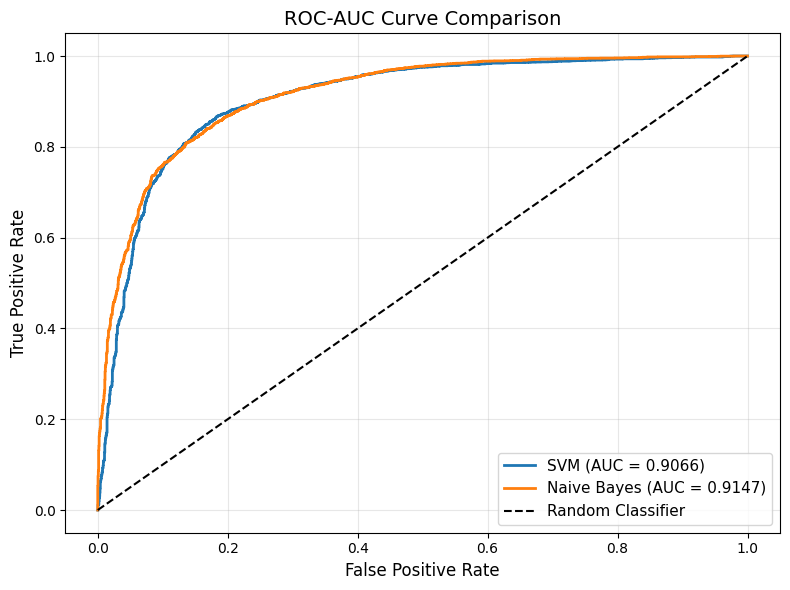

In [29]:
# ROC-AUC Curve Comparison
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_nb = roc_auc_score(y_test, y_prob_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.4f})', linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curve Comparison', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DataSets/Student_Depression_Dataset/roc_auc_curve.png', dpi=300)
plt.show()

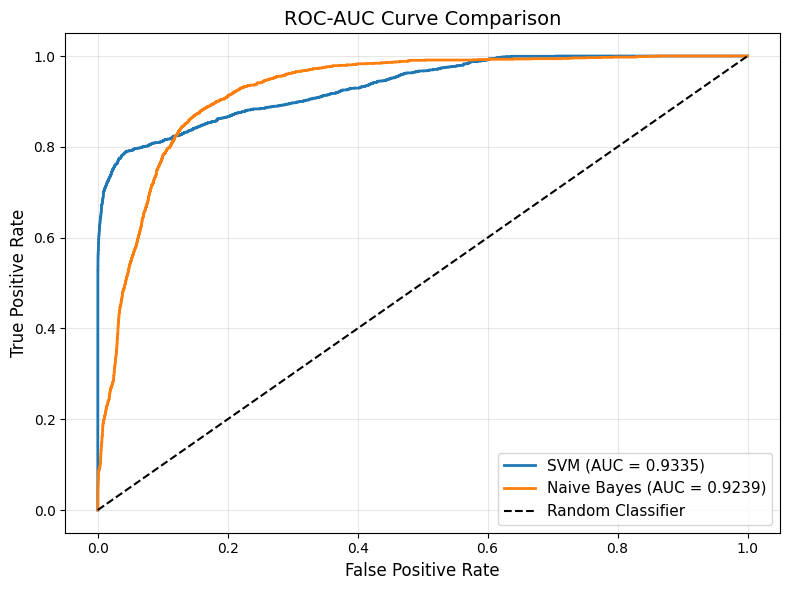

In [28]:
# ROC-AUC Curve Comparison
fpr_svm2, tpr_svm2, _ = roc_curve(y_test2, y_prob_svm2)
fpr_nb2, tpr_nb2, _ = roc_curve(y_test2, y_prob_nb2)
auc_svm2 = roc_auc_score(y_test2, y_prob_svm2)
auc_nb2 = roc_auc_score(y_test2, y_prob_nb2)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm2, tpr_svm2, label=f'SVM (AUC = {auc_svm2:.4f})', linewidth=2)
plt.plot(fpr_nb2, tpr_nb2, label=f'Naive Bayes (AUC = {auc_nb2:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curve Comparison', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DataSets/diabetes_prediction_dataset/roc_auc_curve.png', dpi=300)
plt.show()


In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    'Model': ['SVM (RBF)', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_nb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_nb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_nb)
    ],
    'ROC-AUC': [auc_svm, auc_nb]
})

# Format to 4 decimal places
results.iloc[:, 1:] = results.iloc[:, 1:].round(4)
results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM (RBF),0.8432,0.8530,0.8846,0.8685,0.9066
1,Naive Bayes,0.8389,0.8634,0.8610,0.8622,0.9147


In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results2 = pd.DataFrame({
    'Model': ['SVM (RBF)', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test2, y_pred_svm2),
        accuracy_score(y_test2, y_pred_nb2)
    ],
    'Precision': [
        precision_score(y_test2, y_pred_svm2),
        precision_score(y_test2, y_pred_nb2)
    ],
    'Recall': [
        recall_score(y_test2, y_pred_svm2),
        recall_score(y_test2, y_pred_nb2)
    ],
    'F1-Score': [
        f1_score(y_test2, y_pred_svm2),
        f1_score(y_test2, y_pred_nb2)
    ],
    'ROC-AUC': [auc_svm2, auc_nb2]
})

# Format to 4 decimal places
results2.iloc[:, 1:] = results2.iloc[:, 1:].round(4)
results2


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM (RBF),0.9645,0.9723,0.5994,0.7416,0.9335
1,Naive Bayes,0.9046,0.4574,0.6594,0.5401,0.9239
